torch.Size([40, 12])


/teamspace/studios/this_studio/Reachability_aware_MPPI/src/dynamics/bicycle_like_dynamics.py:50: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  self.L = torch.tensor(self.lf + self.lr, device=self._device, dtype=self._dtype)
/teamspace/studios/this_studio/Reachability_aware_MPPI/src/dynamics/bicycle_like_dynamics.py:219: UserWarning: The use of `x.T` on tensors of dimension other than 2 to reverse their shape is deprecated and it will throw an error in a future release. Consider `x.mT` to transpose batches of matrices or `x.permute(*torch.arange(x.ndim - 1, -1, -1))` to reverse the dimensions of a tensor. (Triggered internally at /pytorch/aten/src/ATen/native/TensorShape.cpp:4413.)
  vec = magnitude.T * eig_vec
/home/zeus/miniconda3/envs/cloudspace/lib/python3.10/site-packages/matplotlib/cbook.py:1699: ComplexWarning: Casting complex val

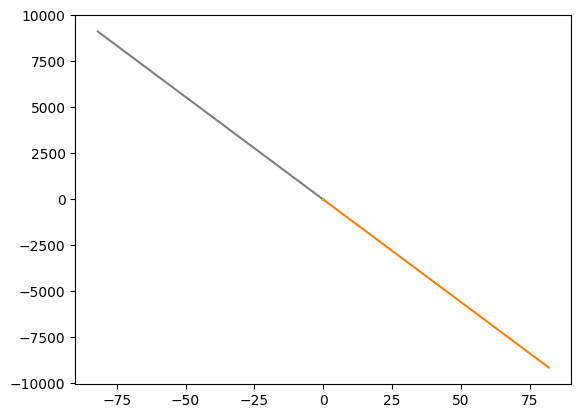

In [1]:
import torch
import numpy as np
import tqdm
import sys, os
sys.path.append(os.path.dirname(os.path.dirname(os.path.abspath(os.getcwd()))))
from src.dynamics.bicycle_like_dynamics import Bicycle_Dynamics
import matplotlib.pyplot as plt


D = Bicycle_Dynamics()

inital_state = torch.Tensor([0,0,0,8,0,0.1])
inital_state = inital_state.unsqueeze(0)
inital_input = torch.Tensor([1,0])
inital_input = inital_input.unsqueeze(0)
state_ = inital_state
input_ = inital_input
# D.linearized_state_space(state_,input_)
step_size = 20
inputs = inital_input.repeat(step_size, 1)
# print(inputs)
'''
required elements : 
current state, previous input traj + new one step input(t+horizon)
'''
vec, u_ref = D.spectral_expansion(step_size, state_, inputs)

for i in range(12):
    plt.plot([0,vec[0,i]], [0,vec[1,i]])
# plt.plot([0, uncontrolled_state[0,0]], [0, uncontrolled_state[1,0]])
# print(uncontrolled_state[0,0])
# print(vec[0,0])
# print(z[0,0])
# plt.gca().set_aspect('equal', adjustable='box')
plt.show()

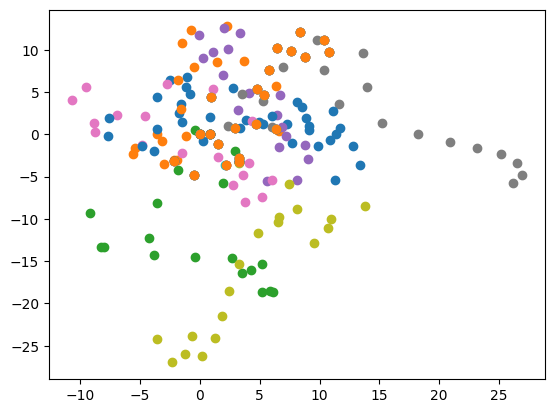

In [2]:
'''
requirement : u_ref, step_size, inital_state,D
'''

for i in range(u_ref.shape[1]):
    u_seq = u_ref[:,i].reshape(step_size, 2)
    state_seq = torch.zeros(step_size + 1,6)
    state = inital_state
    state_seq[0,:] = inital_state
    for t in range(step_size):
        u_seq_clamp = torch.clamp(u_seq[t,:], D.u_min, D.u_max)
        u_seq_clamp = u_seq[t,:]
        next_state = D.linearized_forward(state, u_seq_clamp.unsqueeze(0)) # D.dynamics(state, u_seq[t,:].unsqueeze(0))
        next_state = next_state.unsqueeze(0)
        state_seq[t + 1, :] = next_state
        state = next_state

    x = state_seq[:,0]
    y = state_seq[:,1]
    plt.scatter(x,y)
# plt.gca().set_aspect('equal', adjustable='box')
plt.show()


In [18]:
u_seq_clamp = torch.clamp(u_seq[2,:], D.u_min, D.u_max)
print(u_seq[2,:])
print(u_seq_clamp)

tensor([-9.9907, -0.4128])
tensor([-5.0000, -0.3400])
